# Entrenamiento — (XGBoost multiclase + calibración isotónica)

Este notebook reproduce **paso a paso** el flujo de [`src/model/train.py`](../src/model/train.py): split temporal, entrenamiento del modelo base, calibración isotónica One-vs-Rest en validación y evaluación en test.

**Prerrequisitos**

- Dataset de features: `data/processed/features_dataset.csv` (generar con `python -m src.feature_engineering` desde la raíz del repo).
- Kernel recomendado: **Python (lab01)** (ver [README.md](../README.md)).

**Salidas** (al ejecutar la última celda): `models/final_xgboost.pkl` y `reports/training_summary.txt` (mismo contenido que `python -m src.model.train`). Al ejecutar las celdas con gráficos, las PNG quedan en `reports/figures/02_training/`.

**Comando equivalente en CLI:** `python -m src.model.train`

In [37]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.model.calibration import calibrate_isotonic, evaluate_probabilities
from src.model.train import (
    _file_md5,
    _result_counts,
    _top_feature_importances,
    build_xy,
    drop_mirror,
    fit_base_model,
    infer_feature_columns,
    load_features,
    temporal_split,
)
from src.notebook_figures import save_notebook_figure
from src.utils import PROJECT_ROOT, REPORTS_DIR, set_seed, setup_logging

sns.set_theme(style="whitegrid")
setup_logging()
set_seed(42)

In [38]:
from src.utils import PROCESSED_DIR

FEATURES_PATH = PROCESSED_DIR / "features_dataset.csv"
MODEL_OUT = PROJECT_ROOT / "models" / "final_xgboost.pkl"
REPORT_OUT = REPORTS_DIR / "training_summary.txt"

if not FEATURES_PATH.is_file():
    raise FileNotFoundError(
        f"No existe {FEATURES_PATH}. Ejecuta desde la raíz: python -m src.feature_engineering"
    )
print("CSV features:", FEATURES_PATH.resolve())

CSV features: C:\Users\echoe\Desktop\lab01\data\processed\features_dataset.csv


In [39]:
df = load_features(FEATURES_PATH)
train_df, val_df, test_df = temporal_split(df)
val_eval = drop_mirror(val_df)
test_eval = drop_mirror(test_df)

print("Filas totales:", len(df))
print("\nConteo por año (muestra):")
display(df["year"].value_counts().sort_index().tail(8))

split_info = pd.DataFrame(
    {
        "split": ["train (year<=2018, con espejo)", "val raw (2019–2022)", "val sin espejo", "test raw (>2022)", "test sin espejo"],
        "n_filas": [len(train_df), len(val_df), len(val_eval), len(test_df), len(test_eval)],
    }
)
display(split_info)

print("Distribución result — train (con espejo):", _result_counts(train_df))
print("Distribución result — validation (sin espejo):", _result_counts(val_eval))
print("Distribución result — test (sin espejo):", _result_counts(test_eval))

Filas totales: 47232

Conteo por año (muestra):


year
2019    2156
2020     682
2021    2130
2022    1812
2023    1894
2024    2302
2025    1852
2026     310
Name: count, dtype: int64

,split,n_filas
0,"train (year<=2018, con espejo)",34094
1,val raw (2019–2022),6780
2,val sin espejo,3390
3,test raw (>2022),6358
4,test sin espejo,3179


Distribución result — train (con espejo): {0: 12983, 1: 8128, 2: 12983}
Distribución result — validation (sin espejo): {0: 1645, 1: 771, 2: 974}
Distribución result — test (sin espejo): {0: 1440, 1: 746, 2: 993}


## Columnas de features

Se usan las mismas reglas que el script: columnas numéricas excluyendo metadatos (`match_id`, `date`, equipos, `result`, `sample_weight`, etc.). La calibración **isotónica OvR** ajusta tres isótonas sobre las probabilidades crudas del XGBoost en el conjunto de validación 2019–2022 (sin filas espejo `_m`), sin re-entrenar el árbol base. Ver [`src/model/calibration.py`](../src/model/calibration.py).

In [40]:
features = infer_feature_columns(df)
if not features:
    raise ValueError("No quedaron columnas numéricas de features.")
print(f"Número de features: {len(features)}")
print(features)

Número de features: 20
['diff_elo', 'diff_fifa_rank', 'diff_top5_ratio', 'diff_win_ratio', 'diff_xg', 'elo_A', 'elo_B', 'fifa_rank_A', 'fifa_rank_B', 'is_neutral', 'squad_value_A', 'squad_value_B', 'squad_value_ratio', 'top5_ratio_A', 'top5_ratio_B', 'tournament_weight', 'win_ratio_50_A', 'win_ratio_50_B', 'xg_computed_A', 'xg_computed_B']


In [41]:
X_train, y_train, w_train = build_xy(train_df, features)
base_model = fit_base_model(X_train, y_train, w_train)
print("Modelo base (XGBClassifier) entrenado.")

Modelo base (XGBClassifier) entrenado.


Figura guardada: C:\Users\echoe\Desktop\lab01\reports\figures\02_training\01_feature_importance_xgb_top10.png


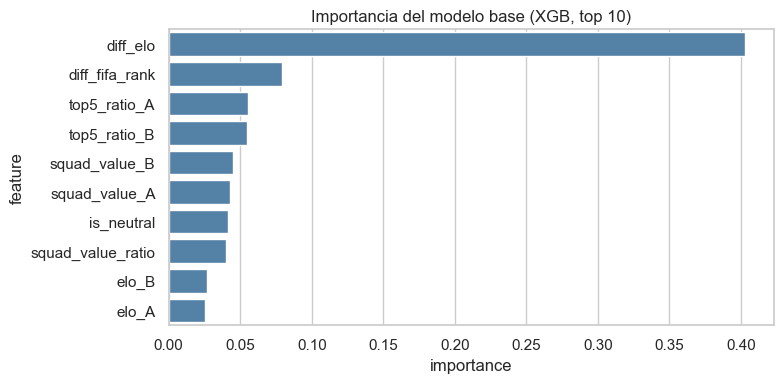

In [42]:
top_imp = _top_feature_importances(base_model, features, top=10)
imp_df = pd.DataFrame(top_imp, columns=["feature", "importance"])
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=imp_df, y="feature", x="importance", ax=ax, color="steelblue")
ax.set_title("Importancia del modelo base (XGB, top 10)")
plt.tight_layout()
path = save_notebook_figure(fig, notebook="02_training", index=1, name="feature_importance_xgb_top10")
print("Figura guardada:", path.resolve())
plt.show()

In [43]:
if len(val_eval) == 0:
    raise ValueError(
        "Validación vacía (2019–2022 sin espejo). Necesitas cobertura temporal en features_dataset.csv."
    )

X_val, y_val, _ = build_xy(val_eval, features)
calibrated = calibrate_isotonic(base_model, X_val, y_val)
print("Calibrador isotónico ajustado en validación.")

Calibrador isotónico ajustado en validación.


In [44]:
metrics: dict[str, dict] = {}
probs_train = calibrated.predict_proba(X_train)
metrics.update(evaluate_probabilities("train", y_train, probs_train))

probs_val = calibrated.predict_proba(X_val)
metrics.update(evaluate_probabilities("validation", y_val, probs_val))

X_test, y_test, _ = build_xy(test_eval, features)
if len(test_eval) > 0:
    probs_test = calibrated.predict_proba(X_test)
    metrics.update(evaluate_probabilities("test", y_test, probs_test))
else:
    metrics["test"] = {"log_loss": float("nan"), "brier_multiclass": float("nan"), "n": 0}

metrics_df = pd.DataFrame.from_dict(metrics, orient="index")
display(metrics_df)

,log_loss,brier_multiclass,n
train,0.913746,0.536278,34094
validation,0.854444,0.503564,3390
test,0.936581,0.522196,3179


## Diagramas de fiabilidad (validación, sin espejo)

Para cada clase `k ∈ {0,1,2}` se agrupan las predicciones calibradas `p_k` en bins en `[0,1]` y se compara la **media de p_k** en el bin con la **frecuencia observada** de que `y == k`. La diagonal representa calibración perfecta.

Figura guardada: C:\Users\echoe\Desktop\lab01\reports\figures\02_training\02_reliability_diagrams_validation.png


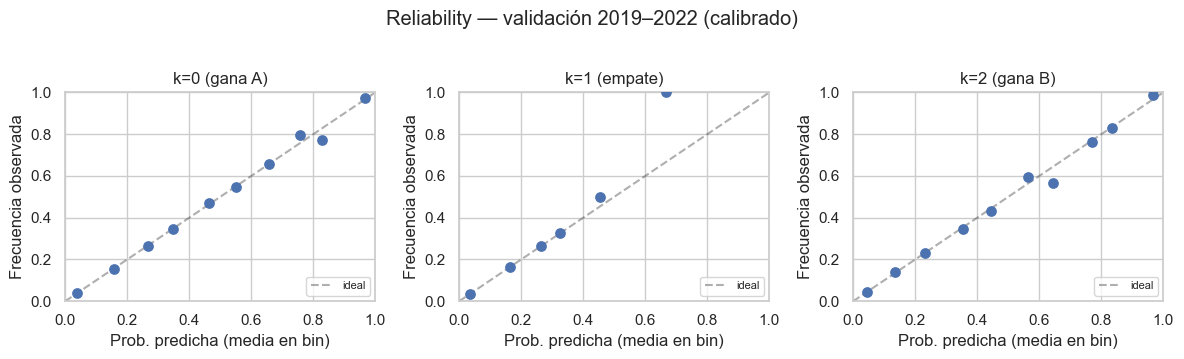

In [45]:
n_bins = 10
y_v = np.asarray(y_val, dtype=int)
pv = np.asarray(probs_val, dtype=float)
titles = ["k=0 (gana A)", "k=1 (empate)", "k=2 (gana B)"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
edges = np.linspace(0.0, 1.0, n_bins + 1)
for k, ax, title in zip([0, 1, 2], axes, titles):
    p = pv[:, k]
    obs = (y_v == k).astype(float)
    mean_p, mean_o = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (p >= lo) & (p < hi) if hi < 1.0 else (p >= lo) & (p <= hi)
        if not m.any():
            continue
        mean_p.append(float(p[m].mean()))
        mean_o.append(float(obs[m].mean()))
    ax.plot([0, 1], [0, 1], "k--", alpha=0.35, label="ideal")
    ax.scatter(mean_p, mean_o, s=45, zorder=3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Prob. predicha (media en bin)")
    ax.set_ylabel("Frecuencia observada")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
plt.suptitle("Reliability — validación 2019–2022 (calibrado)", y=1.02)
plt.tight_layout()
path = save_notebook_figure(fig, notebook="02_training", index=2, name="reliability_diagrams_validation")
print("Figura guardada:", path.resolve())
plt.show()

Figura guardada: C:\Users\echoe\Desktop\lab01\reports\figures\02_training\03_max_confidence_validation.png


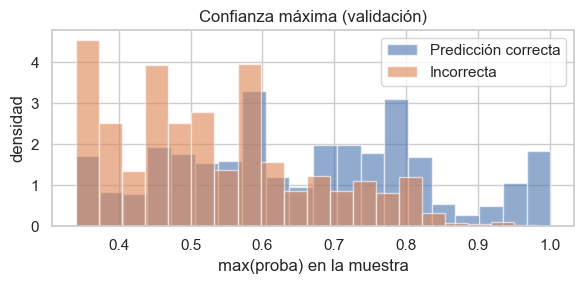

In [46]:
pred_class = np.argmax(probs_val, axis=1)
correct = pred_class == y_v
max_p = probs_val.max(axis=1)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(max_p[correct], bins=20, alpha=0.6, label="Predicción correcta", density=True)
ax.hist(max_p[~correct], bins=20, alpha=0.6, label="Incorrecta", density=True)
ax.set_xlabel("max(proba) en la muestra")
ax.set_ylabel("densidad")
ax.set_title("Confianza máxima (validación)")
ax.legend()
plt.tight_layout()
path = save_notebook_figure(fig, notebook="02_training", index=3, name="max_confidence_validation")
print("Figura guardada:", path.resolve())
plt.show()

In [47]:
MODEL_OUT.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(calibrated, MODEL_OUT)
print("Modelo guardado:", MODEL_OUT.resolve())

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
lines = [
    "=== Resumen entrenamiento (XGBoost + isotónica) ===",
    f"CSV entrada: {FEATURES_PATH}",
    f"Modelo: {MODEL_OUT}",
    "",
    "Hiperparámetros XGBClassifier (base):",
    "  objective=multi:softprob, num_class=3, n_estimators=150, max_depth=4,",
    "  learning_rate=0.05, random_state=42, eval_metric=mlogloss, tree_method=hist, n_jobs=-1",
    "",
    "Calibración: IsotonicCalibratedClassifier (OvR isotónico + renorm sobre validación 2019–2022; "
    "equiv. a isotónica sklearn sin re-ajustar el XGB base; sklearn 1.8 sin cv='prefit').",
    "",
    "Features numéricas (orden alfabético):",
    "  " + ", ".join(features),
    "",
    "Conteo filas por split:",
    f"  train (year<=2018, con espejo): {len(train_df)}",
    f"  validation raw (2019–2022): {len(val_df)} | sin espejo: {len(val_eval)}",
    f"  test raw (year>2022): {len(test_df)} | sin espejo: {len(test_eval)}",
    "",
    "Distribución result (train, con espejo): " + str(_result_counts(train_df)),
    "Distribución result (validation, sin espejo): " + str(_result_counts(val_eval)),
    "Distribución result (test, sin espejo): " + str(_result_counts(test_eval)),
    "",
    "Métricas (log_loss con labels=[0,1,2]):",
]
for split in ("train", "validation", "test"):
    m = metrics[split]
    if m["n"] > 0:
        lines.append(
            f"  {split}: n={m['n']} log_loss={m['log_loss']:.6f} "
            f"brier_multiclass={m['brier_multiclass']:.6f}"
        )
    else:
        lines.append(f"  {split}: n=0 (omitido)")

lines.append("")
lines.append("Importancia (base XGB, top 10):")
for name, score in _top_feature_importances(base_model, features):
    lines.append(f"  {name}: {score:.6f}")

lines.append("")
lines.append(f"MD5 modelo ({MODEL_OUT.name}): {_file_md5(MODEL_OUT)}")
REPORT_OUT.write_text("\n".join(lines) + "\n", encoding="utf-8")
print("Reporte:", REPORT_OUT.resolve())

Modelo guardado: C:\Users\echoe\Desktop\lab01\models\final_xgboost.pkl
Reporte: C:\Users\echoe\Desktop\lab01\reports\training_summary.txt


Listo. Para repetir el entrenamiento sin notebook: `python -m src.model.train` (mismas rutas por defecto).